In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import plotnine as pn
import seaborn as sns
import matplotlib
import os
from pyhere import here
from janitor import clean_names

pd.set_option('display.max_columns', None)
pd.options.mode.copy_on_write = True
matplotlib.rcParams.update({'savefig.bbox': 'tight'})
pn.theme_set(pn.theme_light())

In [2]:
df24 = pd.read_csv(here('data/analytic_data2024.csv'), skiprows = 1)
df25 = pd.read_csv(here('data/analytic_data2025_v3.csv'), skiprows = 1)

In [16]:
df = df24.merge(df25, 'outer')
df.groupby(['year', 'state'])['v159_rawvalue'].mean()

year  state
2024  AK            NaN
      AL       2.780301
      AR       2.818707
      AZ            NaN
      CA       2.808907
                 ...   
2025  VT            NaN
      WA       2.838760
      WI       3.030614
      WV            NaN
      WY       3.291146
Name: v159_rawvalue, Length: 104, dtype: float64

/Users/jp/Documents/github_projects/Michelle/show-your-work/.venv/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 23 rows containing non-finite values.


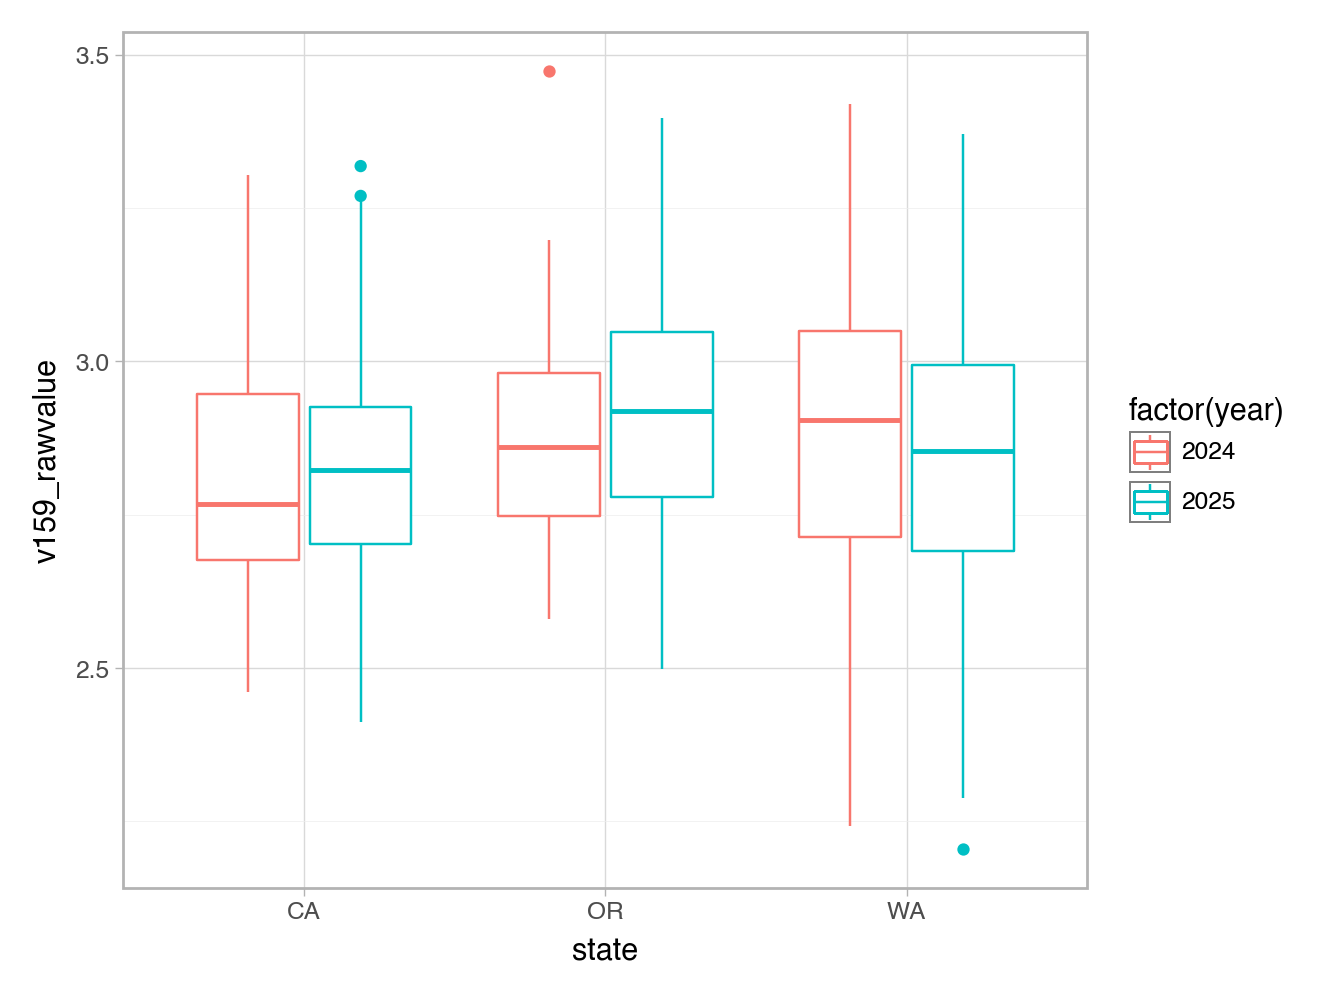

In [ ]:
pn.ggplot.show(
  pn.ggplot(df.loc[df['state'].isin(['CA', 'OR', 'WA'])],
            pn.aes('state',
                   'v159_rawvalue')) # Reading Scores raw value
  + pn.geom_boxplot(pn.aes(color = 'factor(year)'))
)

In [ ]:
# url = 'https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'
# import requests

# response = requests.get(url)
# mapp = response.json()
# mapp['features'][0]

{'type': 'Feature',
 'properties': {'GEO_ID': '0500000US01001',
  'STATE': '01',
  'COUNTY': '001',
  'NAME': 'Autauga',
  'LSAD': 'County',
  'CENSUSAREA': 594.436},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-86.496774, 32.344437],
    [-86.717897, 32.402814],
    [-86.814912, 32.340803],
    [-86.890581, 32.502974],
    [-86.917595, 32.664169],
    [-86.71339, 32.661732],
    [-86.714219, 32.705694],
    [-86.413116, 32.707386],
    [-86.411172, 32.409937],
    [-86.496774, 32.344437]]]},
 'id': '01001'}

In [ ]:
# map_df = pd.json_normalize(mapp['features'],
#                   record_path = None,
#                   meta = ['type',
#                           ['properties', 'GEO_ID'],
#                           ['properties', 'STATE'],
#                           ['properties', 'COUNTY'],
#                           ['properties', 'NAME'],
#                           ['properties', 'LSAD'],
#                           ['properties', 'CENSUSAREA'],
#                           ['geometry', 'type'],
#                           ['geometry', 'coordinates'],
#                           'id'
#                           ]).clean_names(case_type = 'snake')

# map_df = map_df.rename(columns = {'properties_geo_id': 'geo_id',
#                          'properties_state': 'statecode',
#                          'properties_county': 'county_code',
#                          'properties_name': 'county',
#                          'properties_lsad': 'county_type',
#                          'properties_censusarea': 'census_area',
#                          'geometry_coordinates': 'coordinates'
#                          })

# county_df = map_df.loc[map_df['county_type'] == 'County']
# county_df = county_df.drop(columns = ['type', 'county_type'])
# county_df.head()

,id,geo_id,statecode,county_code,county,census_area,geometry_type,coordinates
0,01001,0500000US01001,01,001,Autauga,594.436,Polygon,"[[[-86.496774, 32.344437], [-86.717897, 32.402..."
1,01009,0500000US01009,01,009,Blount,644.776,Polygon,"[[[-86.577799, 33.765316], [-86.759144, 33.840..."
2,01017,0500000US01017,01,017,Chambers,596.531,Polygon,"[[[-85.184131, 32.870525], [-85.123421, 32.772..."
3,01021,0500000US01021,01,021,Chilton,692.854,Polygon,"[[[-86.517344, 33.020566], [-86.515959, 32.929..."
4,01033,0500000US01033,01,033,Colbert,592.619,Polygon,"[[[-88.139988, 34.581703], [-88.139246, 34.587..."


In [ ]:
columns = df.loc[:, 'statecode':'year'].columns.tolist()
columns = columns + ['v011_rawvalue']

df = df.loc[:, columns].rename(columns = {'v011_rawvalue': 'adult_obesity'})

In [ ]:
# county_df[['id', 'statecode', 'county_code']] = county_df[['id', 'statecode', 'county_code']].astype(int)
# county_df['census_area'] = county_df['census_area'].astype(float)

In [94]:
df.loc[df['statecode'] == 1, 'county']
df['county_drop'] = df['county'].str.replace(' County', '')
df = df.rename(columns = {'county': 'county_drop',
                     'county_drop': 'county'})

In [ ]:
# merged = pd.merge(df, county_df.rename(columns={'state_code': 'statecode'}), how='left', on=['statecode', 'county'])

In [ ]:
# from shapely.geometry import Polygon

# # left off here
# merged = gpd.GeoDataFrame(
#     merged,
#     geometry = merged['coordinates'].apply(lambda x: Polygon(x[0])),
#     crs = 'EPSG:4326'  # WGS84 (lon/lat)
# )